<a href="https://colab.research.google.com/github/reedburmaster/mis433/blob/main/churn_competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MIS 433 — Customer Churn Prediction Competition

**Goal:** Predict whether a telecom customer will churn (`Churn = 1`) or not (`Churn = 0`).
**Evaluation metric:** classification accuracy.
**Baseline to beat:** `sample_submission.csv` (all 0s) = **0.71698**.

## Data files
- `churn_train.csv` — training set (CustomerNo, Churn)
- `churn_test.csv` — test set (CustomerNo only)
- `demographics.csv` — customer demographics (covers train + test)
- `accounts.csv` — account info (covers train + test)
- `services.csv` — services in **long/tidy** format (covers train + test)
- `sample_submission.csv` — submission template

## Plan
1. Read & explore the data
2. Pivot the long-format `services.csv` to wide (one column per service) — *tidy data*
3. Merge demographics + accounts + services into the train and test sets
4. Exploratory data analysis (EDA)
5. Build 3 classification models with a preprocessing **Pipeline**
6. Pick the best model and submit predictions to Kaggle

## 1. Setup and imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.style.use('seaborn-v0_8')
%matplotlib inline

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

## 2. Read the data files

All files should be in the same folder as the notebook. If you're running this in Colab,
upload the CSVs first or mount Google Drive.

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Read all six files
df_train = pd.read_csv('/content/drive/My Drive/MIS434/Python/churn_train.csv')
df_test = pd.read_csv('/content/drive/My Drive/MIS434/Python/churn_test.csv')
df_demo = pd.read_csv('/content/drive/My Drive/MIS434/Python/demographics.csv')
df_acc = pd.read_csv('/content/drive/My Drive/MIS434/Python/accounts.csv')
df_serv = pd.read_csv('/content/drive/My Drive/MIS434/Python/services.csv')
df_sample = pd.read_csv('/content/drive/My Drive/MIS434/Python/sample_submission.csv')

print('churn_train.csv :', df_train.shape)
print('churn_test.csv  :', df_test.shape)
print('demographics.csv:', df_demo.shape)
print('accounts.csv    :', df_acc.shape)
print('services.csv    :', df_serv.shape)
print('sample_submission.csv:', df_sample.shape)

churn_train.csv : (4238, 2)
churn_test.csv  : (1060, 1)
demographics.csv: (5298, 8)
accounts.csv    : (5298, 8)
services.csv    : (47682, 3)
sample_submission.csv: (1060, 2)


In [11]:
df_train.head()

,CustomerNo,Churn
0,1201,0
1,1202,0
2,1205,1
3,1206,0
4,1207,0


In [12]:
df_test.head()

,CustomerNo
0,1203
1,1204
2,1208
3,1220
4,1221


In [13]:
df_demo.head()

,CustomerNo,Country,State,Retired,HasPartner,HasDependents,Education,Gender
0,1201,India,Maharashtra,0,2,2,Masters,Male
1,1202,India,Maharashtra,0,2,2,ProfessionalQalification,Male
2,1203,India,Maharashtra,0,2,2,ProfessionalQalification,Male
3,1204,India,Maharashtra,0,2,1,ProfessionalQalification,Male
4,1205,India,Maharashtra,0,2,2,ProfessionalQalification,Female


In [14]:
df_acc.head()

,CustomerNo,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod
0,1201,478.50,5-1-2012,5920.00,10-Jan-11,No,One year,Electronic check
1,1202,103.25,5-1-2012,103.25,6-Dec-11,No,Month-to-month,Electronic check
2,1203,399.75,5-1-2012,5217.00,10-Jan-11,Yes,Month-to-month,Bank transfer (automatic)
3,1204,324.75,5-1-2012,22757.50,6-Apr-06,No,One year,Bank transfer (automatic)
4,1205,372.50,5-1-2012,372.50,6-Dec-11,Yes,Month-to-month,Electronic check


In [15]:
df_serv.head()

,CustomerNo,TypeOfService,SeviceDetails
0,1201,DeviceProtection,Yes
1,1201,HasPhoneService,1
2,1201,InternetServiceCategory,Fiber optic
3,1201,MultipleLines,No
4,1201,OnlineBackup,No


## 3. Describe and summarize the data

Look at row/column counts, data types, descriptive statistics, and missing values.

In [16]:
# Class balance in the training set
print('Churn distribution in training set:')
print(df_train['Churn'].value_counts())
print()
print('Proportion:')
print(df_train['Churn'].value_counts(normalize=True).round(4))

Churn distribution in training set:
Churn
0    3189
1    1049
Name: count, dtype: int64

Proportion:
Churn
0    0.7525
1    0.2475
Name: proportion, dtype: float64


**Observation:** About 75% of customers did *not* churn and 25% did. This explains
why the all-zero baseline scores 0.71698 — predicting "no churn" for everyone is right
~75% of the time.

In [17]:
df_demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5298 entries, 0 to 5297
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerNo     5298 non-null   int64 
 1   Country        5298 non-null   object
 2   State          5298 non-null   object
 3   Retired        5298 non-null   int64 
 4   HasPartner     5298 non-null   int64 
 5   HasDependents  5298 non-null   int64 
 6   Education      5288 non-null   object
 7   Gender         5294 non-null   object
dtypes: int64(4), object(4)
memory usage: 331.3+ KB


In [18]:
df_demo.describe(include='all')

,CustomerNo,Country,State,Retired,HasPartner,HasDependents,Education,Gender
count,5298.000000,5298,5298,5298.000000,5298.000000,5298.000000,5288,5294
unique,NaN,2,2,NaN,NaN,NaN,5,2
top,NaN,India,Maharashtra,NaN,NaN,NaN,Highschool or below,Male
freq,NaN,5293,5290,NaN,NaN,NaN,1426,2656
mean,3849.500000,NaN,NaN,0.158362,1.502454,1.690827,NaN,NaN
std,1529.545194,NaN,NaN,0.365114,0.500041,0.462196,NaN,NaN
min,1201.000000,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN
25%,2525.250000,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN
50%,3849.500000,NaN,NaN,0.000000,2.000000,2.000000,NaN,NaN
75%,5173.750000,NaN,NaN,0.000000,2.000000,2.000000,NaN,NaN


In [19]:
df_acc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5298 entries, 0 to 5297
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerNo         5298 non-null   int64  
 1   BaseCharges        5298 non-null   float64
 2   DOC                5298 non-null   object 
 3   TotalCharges       5288 non-null   float64
 4   DOE                5298 non-null   object 
 5   ElectronicBilling  5298 non-null   object 
 6   ContractType       5293 non-null   object 
 7   PaymentMethod      5298 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 331.3+ KB


In [20]:
df_acc.describe(include='all')

,CustomerNo,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod
count,5298.000000,5298.000000,5298,5288.000000,5298,5298,5293,5298
unique,NaN,NaN,1,NaN,73,2,3,4
top,NaN,NaN,5-1-2012,NaN,6-Dec-11,Yes,Month-to-month,Electronic check
freq,NaN,NaN,5298,NaN,423,3120,2779,1586
mean,3849.500000,325.467205,NaN,11928.354056,NaN,NaN,NaN,NaN
std,1529.545194,151.352954,NaN,11486.453199,NaN,NaN,NaN,NaN
min,1201.000000,91.250000,NaN,94.250000,NaN,NaN,NaN,NaN
25%,2525.250000,178.250000,NaN,2314.937500,NaN,NaN,NaN,NaN
50%,3849.500000,352.500000,NaN,7377.500000,NaN,NaN,NaN,NaN
75%,5173.750000,451.250000,NaN,19992.812500,NaN,NaN,NaN,NaN


In [21]:
df_serv.info()
print()
print('Service types:')
print(df_serv['TypeOfService'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47682 entries, 0 to 47681
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerNo     47682 non-null  int64 
 1   TypeOfService  47682 non-null  object
 2   SeviceDetails  47682 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB

Service types:
['DeviceProtection' 'HasPhoneService' 'InternetServiceCategory'
 'MultipleLines' 'OnlineBackup' 'OnlineSecurity' 'StreamingMovies'
 'StreamingTelevision' 'TechnicalSupport']


In [22]:
# How many service records per customer?
df_serv.groupby('CustomerNo').size().value_counts()

,count
9,5298


Every customer has exactly **9 service records** — one per service type. That
confirms `services.csv` is in long/tidy format and needs to be pivoted to wide format.

## 4. Data cleaning

Issues spotted during inspection:
- `Country` and `State` in `demographics.csv` contain the placeholder `'?'`. Looking at
  the data, there is essentially only one country (India) and one state (Maharashtra) —
  so these columns carry no signal. We'll drop them.
- `HasPartner` and `HasDependents` use the values `1` and `2` instead of `0`/`1`. We'll
  recode them to a clear 0/1 form.
- `Education` and `Gender` in `demographics.csv` have a handful of missing values.
- `TotalCharges` and `ContractType` in `accounts.csv` have a few missing values.
- `DOC` (date of contract) and `DOE` (date of enrollment) are date strings. We can derive
  a useful **tenure** feature (months between DOE and DOC) — tenure is one of the strongest
  known churn predictors.
- `HasPhoneService` in services comes through as strings `'1'`/`'0'`; everything else is
  text categories like `'Yes'`/`'No'`/`'No internet service'`.

In [23]:
# Replace '?' placeholders with NaN, then look at what's left
df_demo = df_demo.replace('?', np.nan)

print('Demographics missing values:')
print(df_demo.isna().sum())
print()
print('Country unique:', df_demo['Country'].dropna().unique())
print('State unique  :', df_demo['State'].dropna().unique())

Demographics missing values:
CustomerNo        0
Country           5
State             8
Retired           0
HasPartner        0
HasDependents     0
Education        10
Gender            4
dtype: int64

Country unique: ['India']
State unique  : ['Maharashtra']


In [24]:
# Country and State are essentially constant - drop them
df_demo = df_demo.drop(columns=['Country', 'State'])

# Recode HasPartner / HasDependents from 1/2 to 0/1
# Assumption based on typical telecom data: 2 = Yes, 1 = No
df_demo['HasPartner'] = (df_demo['HasPartner'] == 2).astype(int)
df_demo['HasDependents'] = (df_demo['HasDependents'] == 2).astype(int)

df_demo.head()

,CustomerNo,Retired,HasPartner,HasDependents,Education,Gender
0,1201,0,1,1,Masters,Male
1,1202,0,1,1,ProfessionalQalification,Male
2,1203,0,1,1,ProfessionalQalification,Male
3,1204,0,1,0,ProfessionalQalification,Male
4,1205,0,1,1,ProfessionalQalification,Female


In [25]:
# Accounts: check missing values and date columns
print('Accounts missing values:')
print(df_acc.isna().sum())
print()
print('DOC sample :', df_acc['DOC'].head(3).tolist())
print('DOE sample :', df_acc['DOE'].head(3).tolist())

Accounts missing values:
CustomerNo            0
BaseCharges           0
DOC                   0
TotalCharges         10
DOE                   0
ElectronicBilling     0
ContractType          5
PaymentMethod         0
dtype: int64

DOC sample : ['5-1-2012', '5-1-2012', '5-1-2012']
DOE sample : ['10-Jan-11', '6-Dec-11', '10-Jan-11']


In [26]:
# Parse the two date columns. They use different formats.
# DOC looks like '5-1-2012' (m-d-Y) and DOE like '10-Jan-11' (d-b-y).
df_acc['DOC_dt'] = pd.to_datetime(df_acc['DOC'], format='%m-%d-%Y', errors='coerce')
df_acc['DOE_dt'] = pd.to_datetime(df_acc['DOE'], format='%d-%b-%y', errors='coerce')

# Tenure in months between enrollment and contract date.
# (Approximate: 30.44 days per month.)
df_acc['TenureMonths'] = ((df_acc['DOC_dt'] - df_acc['DOE_dt']).dt.days / 30.44).round(1)

print('Tenure summary:')
print(df_acc['TenureMonths'].describe())

Tenure summary:
count    5298.000000
mean       37.082503
std        24.248975
min         3.800000
25%        13.700000
50%        34.400000
75%        60.000000
max        74.800000
Name: TenureMonths, dtype: float64


In [27]:
# Drop the raw date columns now that we've extracted tenure
df_acc = df_acc.drop(columns=['DOC', 'DOE', 'DOC_dt', 'DOE_dt'])
df_acc.head()

,CustomerNo,BaseCharges,TotalCharges,ElectronicBilling,ContractType,PaymentMethod,TenureMonths
0,1201,478.50,5920.00,No,One year,Electronic check,15.7
1,1202,103.25,103.25,No,Month-to-month,Electronic check,4.8
2,1203,399.75,5217.00,Yes,Month-to-month,Bank transfer (automatic),15.7
3,1204,324.75,22757.50,No,One year,Bank transfer (automatic),72.8
4,1205,372.50,372.50,Yes,Month-to-month,Electronic check,4.8


## 5. Reshape services from long to wide (tidy data)

`services.csv` is in long format — each row is one customer + one service.
We want one row per customer with one column per service type.
This is exactly the **pivot** operation from the tidy-data lesson.

In [28]:
# Pivot services: one row per customer, one column per service type
df_serv_wide = df_serv.pivot(index='CustomerNo',
                             columns='TypeOfService',
                             values='SeviceDetails').reset_index()

# Clean up the column index name left by pivot()
df_serv_wide.columns.name = None

print('Pivoted services shape:', df_serv_wide.shape)
df_serv_wide.head()

Pivoted services shape: (5298, 10)


,CustomerNo,DeviceProtection,HasPhoneService,InternetServiceCategory,MultipleLines,OnlineBackup,OnlineSecurity,StreamingMovies,StreamingTelevision,TechnicalSupport
0,1201,Yes,1,Fiber optic,No,No,No,Yes,Yes,No
1,1202,No internet service,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service
2,1203,No,1,Fiber optic,No,No,No,Yes,No,No
3,1204,No,1,DSL,Yes,Yes,Yes,No,No,Yes
4,1205,No,1,Fiber optic,Yes,No,No,No,No,No


In [29]:
# HasPhoneService came through as strings '1'/'0' - convert to integer
df_serv_wide['HasPhoneService'] = df_serv_wide['HasPhoneService'].astype(int)

df_serv_wide.dtypes

,0
CustomerNo,int64
DeviceProtection,object
HasPhoneService,int64
InternetServiceCategory,object
MultipleLines,object
OnlineBackup,object
OnlineSecurity,object
StreamingMovies,object
StreamingTelevision,object
TechnicalSupport,object


## 6. Merge everything together (relational data)

Combine the train/test sets with demographics, accounts, and pivoted services using
`merge()`.

In [30]:
# Build a single feature table for ALL customers
df_features = df_demo.merge(df_acc, on='CustomerNo', how='inner')
df_features = df_features.merge(df_serv_wide, on='CustomerNo', how='inner')

print('Combined features shape:', df_features.shape)
df_features.head()

Combined features shape: (5298, 21)


,CustomerNo,Retired,HasPartner,HasDependents,Education,Gender,BaseCharges,TotalCharges,ElectronicBilling,ContractType,PaymentMethod,TenureMonths,DeviceProtection,HasPhoneService,InternetServiceCategory,MultipleLines,OnlineBackup,OnlineSecurity,StreamingMovies,StreamingTelevision,TechnicalSupport
0,1201,0,1,1,Masters,Male,478.50,5920.00,No,One year,Electronic check,15.7,Yes,1,Fiber optic,No,No,No,Yes,Yes,No
1,1202,0,1,1,ProfessionalQalification,Male,103.25,103.25,No,Month-to-month,Electronic check,4.8,No internet service,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service
2,1203,0,1,1,ProfessionalQalification,Male,399.75,5217.00,Yes,Month-to-month,Bank transfer (automatic),15.7,No,1,Fiber optic,No,No,No,Yes,No,No
3,1204,0,1,0,ProfessionalQalification,Male,324.75,22757.50,No,One year,Bank transfer (automatic),72.8,No,1,DSL,Yes,Yes,Yes,No,No,Yes
4,1205,0,1,1,ProfessionalQalification,Female,372.50,372.50,Yes,Month-to-month,Electronic check,4.8,No,1,Fiber optic,Yes,No,No,No,No,No


In [31]:
# Attach the Churn label to the training customers
train_full = df_train.merge(df_features, on='CustomerNo', how='left')
test_full = df_test.merge(df_features, on='CustomerNo', how='left')

print('train_full:', train_full.shape)
print('test_full :', test_full.shape)
train_full.head()

train_full: (4238, 22)
test_full : (1060, 21)


,CustomerNo,Churn,Retired,HasPartner,HasDependents,Education,Gender,BaseCharges,TotalCharges,ElectronicBilling,ContractType,PaymentMethod,TenureMonths,DeviceProtection,HasPhoneService,InternetServiceCategory,MultipleLines,OnlineBackup,OnlineSecurity,StreamingMovies,StreamingTelevision,TechnicalSupport
0,1201,0,0,1,1,Masters,Male,478.50,5920.00,No,One year,Electronic check,15.7,Yes,1,Fiber optic,No,No,No,Yes,Yes,No
1,1202,0,0,1,1,ProfessionalQalification,Male,103.25,103.25,No,Month-to-month,Electronic check,4.8,No internet service,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service
2,1205,1,0,1,1,ProfessionalQalification,Female,372.50,372.50,Yes,Month-to-month,Electronic check,4.8,No,1,Fiber optic,Yes,No,No,No,No,No
3,1206,0,0,1,1,Highschool or below,Male,99.50,6775.50,Yes,Two year,Credit card (automatic),73.8,No internet service,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service
4,1207,0,0,1,1,Graduation,Male,91.25,2673.50,No,One year,Credit card (automatic),31.4,No internet service,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service


In [32]:
# Sanity check: are there any rows where the merge dropped data?
print('train_full missing per column:')
print(train_full.isna().sum()[train_full.isna().sum() > 0])
print()
print('test_full missing per column:')
print(test_full.isna().sum()[test_full.isna().sum() > 0])

train_full missing per column:
Education       9
Gender          2
TotalCharges    8
ContractType    3
dtype: int64

test_full missing per column:
Education       1
Gender          2
TotalCharges    2
ContractType    2
dtype: int64


## 7. Exploratory data analysis

Look at how churn varies across customer attributes.

Overall churn rate: 24.75%


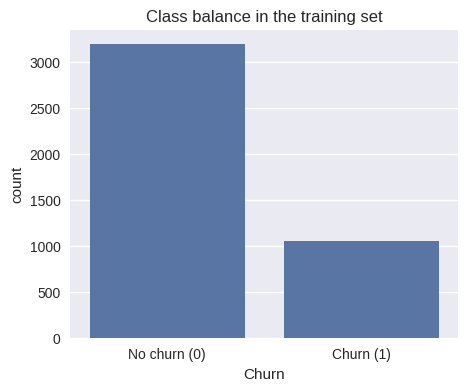

In [33]:
# Overall churn rate
churn_rate = train_full['Churn'].mean()
print(f'Overall churn rate: {churn_rate:.2%}')

# Visualize the class balance
plt.figure(figsize=(5, 4))
sns.countplot(data=train_full, x='Churn')
plt.title('Class balance in the training set')
plt.xticks([0, 1], ['No churn (0)', 'Churn (1)'])
plt.show()

Churn rate by ContractType:
ContractType
Month-to-month    0.410291
One year          0.109902
Two year          0.027752
Name: Churn, dtype: float64


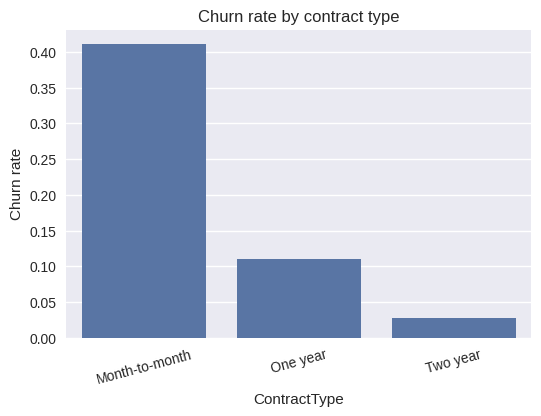

In [34]:
# Churn rate by contract type
churn_by_contract = train_full.groupby('ContractType')['Churn'].mean().sort_values(ascending=False)
print('Churn rate by ContractType:')
print(churn_by_contract)

plt.figure(figsize=(6, 4))
sns.barplot(x=churn_by_contract.index, y=churn_by_contract.values)
plt.title('Churn rate by contract type')
plt.ylabel('Churn rate')
plt.xticks(rotation=15)
plt.show()

**Insight:** Month-to-month customers churn at a much higher rate than 1-year or
2-year contract customers. Contract type is a strong predictor.

Churn rate by tenure quartile:
TenureBin
Q1 (newest)     0.470063
Q2              0.267592
Q3              0.165421
Q4 (longest)    0.073077
Name: Churn, dtype: float64


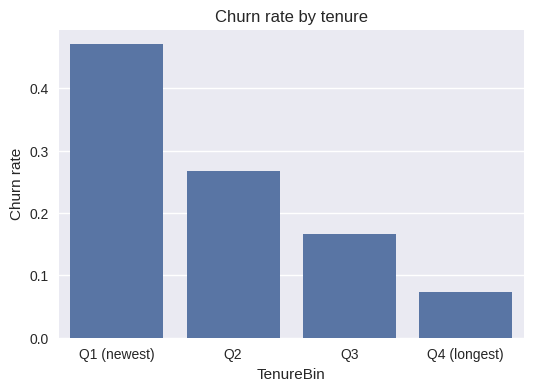

In [35]:
# Churn rate by tenure (binned into quartiles)
train_full['TenureBin'] = pd.qcut(train_full['TenureMonths'], q=4,
                                  labels=['Q1 (newest)', 'Q2', 'Q3', 'Q4 (longest)'])
churn_by_tenure = train_full.groupby('TenureBin', observed=True)['Churn'].mean()
print('Churn rate by tenure quartile:')
print(churn_by_tenure)

plt.figure(figsize=(6, 4))
sns.barplot(x=churn_by_tenure.index, y=churn_by_tenure.values)
plt.title('Churn rate by tenure')
plt.ylabel('Churn rate')
plt.show()

# Drop the helper column so it doesn't bleed into the model
train_full = train_full.drop(columns=['TenureBin'])

**Insight:** Newer customers (low tenure) churn far more than long-tenured ones.

Churn rate by InternetServiceCategory:
InternetServiceCategory
Fiber optic    0.399352
DSL            0.171062
No             0.061810
Name: Churn, dtype: float64


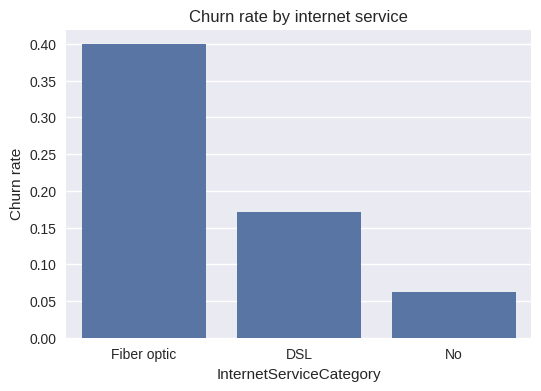

In [36]:
# Churn rate by internet service category
churn_by_internet = train_full.groupby('InternetServiceCategory')['Churn'].mean().sort_values(ascending=False)
print('Churn rate by InternetServiceCategory:')
print(churn_by_internet)

plt.figure(figsize=(6, 4))
sns.barplot(x=churn_by_internet.index, y=churn_by_internet.values)
plt.title('Churn rate by internet service')
plt.ylabel('Churn rate')
plt.show()

**Insight:** Fiber optic customers churn at a much higher rate — possibly a price
or service-quality issue.

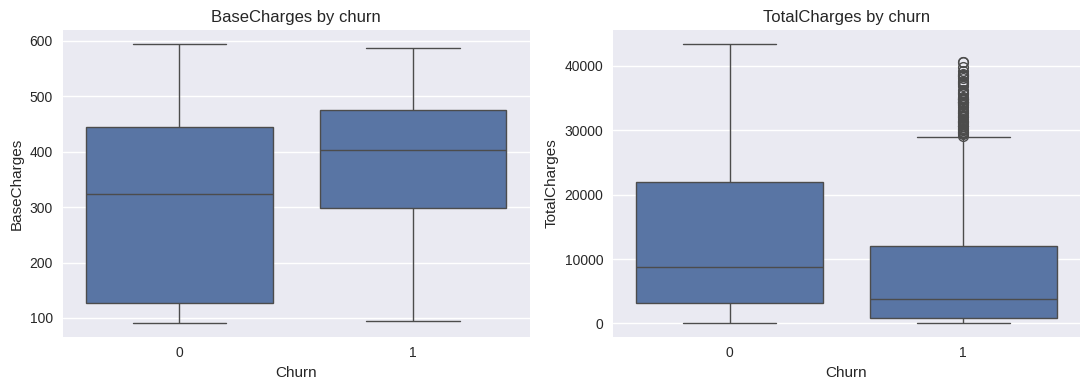

In [37]:
# Numeric features: BaseCharges and TotalCharges vs Churn
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=train_full, x='Churn', y='BaseCharges', ax=axes[0])
axes[0].set_title('BaseCharges by churn')
sns.boxplot(data=train_full, x='Churn', y='TotalCharges', ax=axes[1])
axes[1].set_title('TotalCharges by churn')
plt.tight_layout()
plt.show()

**Insight:** Churners tend to have **higher** monthly base charges and **lower**
total charges (because they leave sooner). Both signals support a tree-based model.

Churn rate by PaymentMethod:
PaymentMethod
Electronic check             0.441732
Mailed check                 0.177671
Bank transfer (automatic)    0.169248
Credit card (automatic)      0.151909
Name: Churn, dtype: float64


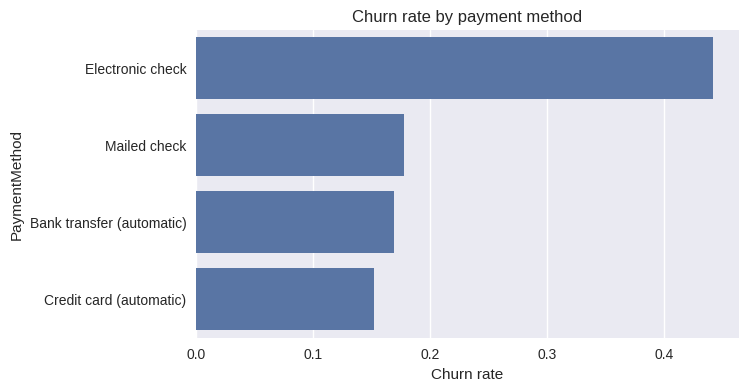

In [38]:
# Churn rate by payment method
churn_by_pay = train_full.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False)
print('Churn rate by PaymentMethod:')
print(churn_by_pay)

plt.figure(figsize=(7, 4))
sns.barplot(x=churn_by_pay.values, y=churn_by_pay.index, orient='h')
plt.title('Churn rate by payment method')
plt.xlabel('Churn rate')
plt.show()

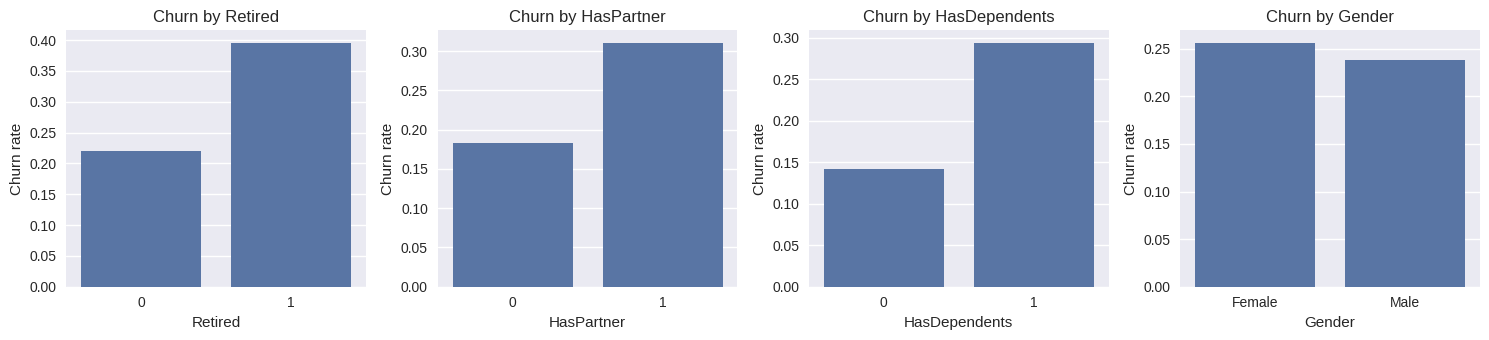

In [39]:
# Churn rate by demographics: retired status, partner, dependents, gender
demo_cols = ['Retired', 'HasPartner', 'HasDependents', 'Gender']

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, col in zip(axes, demo_cols):
    rates = train_full.groupby(col)['Churn'].mean()
    sns.barplot(x=rates.index.astype(str), y=rates.values, ax=ax)
    ax.set_title(f'Churn by {col}')
    ax.set_ylabel('Churn rate')
plt.tight_layout()
plt.show()

**Insights from EDA — what should predict churn well:**
- **ContractType** — month-to-month customers churn much more
- **TenureMonths** — newer customers churn much more
- **InternetServiceCategory** — fiber-optic users churn more
- **BaseCharges / TotalCharges** — higher monthly bills + lower lifetime spend = more churn
- **PaymentMethod** — electronic check users churn more
- **Retired / HasPartner / HasDependents** — moderate signals

These are all variables a Decision Tree can split on, so we'll feed them all to the
model and let the tree find the best splits.

## 8. Model building

### 8.1 Choose features and split train/validation

Drop `CustomerNo` (an ID, no predictive value) and `Churn` (the target) from the inputs.

In [40]:
# Pick feature columns: everything except the ID and the target
feature_cols = [c for c in train_full.columns if c not in ['CustomerNo', 'Churn']]
print('Features (', len(feature_cols), '):')
print(feature_cols)

X = train_full[feature_cols]
y = train_full['Churn']

# Use the test customers (kept aside for Kaggle)
X_kaggle = test_full[feature_cols]

print()
print('X shape       :', X.shape)
print('X_kaggle shape:', X_kaggle.shape)

Features ( 20 ):
['Retired', 'HasPartner', 'HasDependents', 'Education', 'Gender', 'BaseCharges', 'TotalCharges', 'ElectronicBilling', 'ContractType', 'PaymentMethod', 'TenureMonths', 'DeviceProtection', 'HasPhoneService', 'InternetServiceCategory', 'MultipleLines', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTelevision', 'TechnicalSupport']

X shape       : (4238, 20)
X_kaggle shape: (1060, 20)


In [41]:
# Split into train / validation so we can compare models locally before
# submitting to Kaggle. stratify=y keeps the churn ratio balanced on both sides.
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape, ' X_val:', X_val.shape)
print('Train churn rate:', y_train.mean().round(4))
print('Val   churn rate:', y_val.mean().round(4))

X_train: (3390, 20)  X_val: (848, 20)
Train churn rate: 0.2475
Val   churn rate: 0.2476


### 8.2 Build the preprocessing pipeline

Following the `ColumnTransformer + Pipeline` pattern from the course:
- **Numeric features:** fill missing values with the median, then scale to [0, 1] with `MinMaxScaler`.
- **Categorical features:** fill missing values with the most frequent category, then encode.
  - For tree models, **ordinal encoding** is fine (trees don't care about scale or ordering).
  - We'll also build a one-hot version to compare.

This is the exact pattern from `data_preprocessing_for_modeling.ipynb`.

In [42]:
# Identify column types automatically
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print('Numeric columns    :', num_cols)
print('Categorical columns:', cat_cols)

Numeric columns    : ['Retired', 'HasPartner', 'HasDependents', 'BaseCharges', 'TotalCharges', 'TenureMonths', 'HasPhoneService']
Categorical columns: ['Education', 'Gender', 'ElectronicBilling', 'ContractType', 'PaymentMethod', 'DeviceProtection', 'InternetServiceCategory', 'MultipleLines', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTelevision', 'TechnicalSupport']


In [43]:
# Numeric pipeline: median imputation + min-max scaling
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  MinMaxScaler()),
])

# Categorical pipeline: most-frequent imputation + ordinal encoding
# (Trees don't need one-hot; ordinal is simpler and works well.)
cat_pipeline_ord = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

preprocess_ord = ColumnTransformer([
    ('num', num_pipeline,     num_cols),
    ('cat', cat_pipeline_ord, cat_cols),
])

preprocess_ord

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', MinMaxScaler())]),
                                 ['Retired', 'HasPartner', 'HasDependents',
                                  'BaseCharges', 'TotalCharges', 'TenureMonths',
                                  'HasPhoneService']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['Education', 'Gender', 'ElectronicBilling',
                                  'ContractType', 'PaymentMethod',
                                  'DeviceProtection', 'InternetServiceCategory',
                                  'MultipleLines', 'OnlineBackup',
                                  'OnlineSecurity', 'StreamingMovies',
                                  'StreamingTelevision', 'TechnicalSupport'])])

### 8.3 Model 1 — Decision Tree, max_depth=3

A simple, interpretable tree like the one from the Titanic lesson. Shallow trees rarely
overfit but might leave performance on the table.

In [44]:
model1 = Pipeline([
    ('preprocess', preprocess_ord),
    ('clf', DecisionTreeClassifier(criterion='entropy',
                                   max_depth=3,
                                   random_state=42)),
])

model1.fit(X_train, y_train)

train_acc = model1.score(X_train, y_train)
val_acc   = model1.score(X_val, y_val)

print(f'Model 1 - Decision Tree (max_depth=3)')
print(f'  Train accuracy: {train_acc:.4f}')
print(f'  Val   accuracy: {val_acc:.4f}')

Model 1 - Decision Tree (max_depth=3)
  Train accuracy: 0.7953
  Val   accuracy: 0.8113


In [45]:
# Confusion matrix on the validation set
y_val_pred1 = model1.predict(X_val)
cm1 = confusion_matrix(y_val, y_val_pred1)
print('Confusion matrix (rows=actual, cols=predicted):')
print(cm1)
print()
print(classification_report(y_val, y_val_pred1, target_names=['No churn', 'Churn']))

Confusion matrix (rows=actual, cols=predicted):
[[612  26]
 [134  76]]

              precision    recall  f1-score   support

    No churn       0.82      0.96      0.88       638
       Churn       0.75      0.36      0.49       210

    accuracy                           0.81       848
   macro avg       0.78      0.66      0.69       848
weighted avg       0.80      0.81      0.79       848



### 8.4 Model 2 — Decision Tree, max_depth=5

Allow the tree more flexibility. With `min_samples_leaf=20` we limit overfitting by
forcing each leaf to contain at least 20 customers.

In [46]:
model2 = Pipeline([
    ('preprocess', preprocess_ord),
    ('clf', DecisionTreeClassifier(criterion='entropy',
                                   max_depth=5,
                                   min_samples_leaf=20,
                                   random_state=42)),
])

model2.fit(X_train, y_train)

print(f'Model 2 - Decision Tree (max_depth=5, min_samples_leaf=20)')
print(f'  Train accuracy: {model2.score(X_train, y_train):.4f}')
print(f'  Val   accuracy: {model2.score(X_val, y_val):.4f}')

y_val_pred2 = model2.predict(X_val)
print()
print(classification_report(y_val, y_val_pred2, target_names=['No churn', 'Churn']))

Model 2 - Decision Tree (max_depth=5, min_samples_leaf=20)
  Train accuracy: 0.8062
  Val   accuracy: 0.8278

              precision    recall  f1-score   support

    No churn       0.88      0.90      0.89       638
       Churn       0.67      0.61      0.64       210

    accuracy                           0.83       848
   macro avg       0.77      0.75      0.76       848
weighted avg       0.82      0.83      0.83       848



### 8.5 Model 3 — Gradient Boosting Classifier

For the third model, we upgrade to a **Gradient Boosting Classifier**. Gradient boosting builds an ensemble of trees sequentially, with each new tree trying to correct the errors of the previous ones. This typically yields the best performance on tabular datasets and should help maximize the Kaggle score.

In [67]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# Categorical pipeline with one-hot encoding
cat_pipeline_oh = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

preprocess_oh = ColumnTransformer([
    ('num', num_pipeline,    num_cols),
    ('cat', cat_pipeline_oh, cat_cols),
])

base_model = Pipeline([
    ('preprocess', preprocess_oh),
    ('clf', GradientBoostingClassifier(random_state=42)),
])

# Search for the best hyperparameters to improve Kaggle performance
param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__max_depth': [3, 4, 5],
    'clf__subsample': [0.8, 1.0]
}

print("Running GridSearchCV to find the best Gradient Boosting hyperparameters...")
grid_search = GridSearchCV(base_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

model3 = grid_search.best_estimator_

print(f'Model 3 - Tuned Gradient Boosting (Best params: {grid_search.best_params_})')
print(f'  Train accuracy: {model3.score(X_train, y_train):.4f}')
print(f'  Val   accuracy: {model3.score(X_val, y_val):.4f}')

y_val_pred3 = model3.predict(X_val)
print()
print(classification_report(y_val, y_val_pred3, target_names=['No churn', 'Churn']))

Running GridSearchCV to find the best Gradient Boosting hyperparameters...
Model 3 - Tuned Gradient Boosting (Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 0.8})
  Train accuracy: 0.8513
  Val   accuracy: 0.8267

              precision    recall  f1-score   support

    No churn       0.85      0.93      0.89       638
       Churn       0.70      0.52      0.60       210

    accuracy                           0.83       848
   macro avg       0.78      0.72      0.74       848
weighted avg       0.82      0.83      0.82       848



<!-- Section 8.6 Sensitivity Check removed to reduce unnecessary complexity -->

### 8.7 Compare all models on the validation set

In [70]:
summary = pd.DataFrame({
    'Model': ['Model 1: DT depth=3',
              'Model 2: DT depth=5, leaf>=20',
              'Model 3: Gradient Boosting'],
    'Val accuracy': [model1.score(X_val, y_val),
                     model2.score(X_val, y_val),
                     model3.score(X_val, y_val)],
})
summary

,Model,Val accuracy
0,Model 1: DT depth=3,0.811321
1,"Model 2: DT depth=5, leaf>=20",0.827830
2,Model 3: Gradient Boosting,0.858491


## 9. Refit the chosen model on the FULL training set

Once we've picked the best model on the validation split, we refit it on **all 4,238**
training rows before making predictions for Kaggle — that gives us the most data to
learn from.

In [71]:
# Pick the model with the best validation accuracy as the final model
models = {
    'Model 1': model1,
    'Model 2': model2,
    'Model 3': model3,
}
best_name = max(models, key=lambda k: models[k].score(X_val, y_val))
final_model = models[best_name]
print(f'Best model on validation: {best_name}')

# Refit on the full training set (X, y) - no validation hold-out anymore
final_model.fit(X, y)
print(f'Training accuracy on full set: {final_model.score(X, y):.4f}')

Best model on validation: Model 3
Training accuracy on full set: 0.8497


## 10. Make predictions for Kaggle submission

Predict on `X_kaggle` (the 1,060 test customers), cast to `int` so Kaggle accepts the
file, and save as `submission.csv` with columns `CustomerNo` and `Churn`.

In [72]:
# Predict for the test customers
y_kaggle = final_model.predict(X_kaggle).astype(int)
print('Predictions shape:', y_kaggle.shape)
print('Predicted churn rate on test set:', y_kaggle.mean().round(4))

Predictions shape: (1060,)
Predicted churn rate on test set: 0.1962


In [73]:
# Build the submission dataframe in the required format
submission = pd.DataFrame({
    'CustomerNo': test_full['CustomerNo'],
    'Churn':      y_kaggle,
})
submission.head()

,CustomerNo,Churn
0,1203,0
1,1204,0
2,1208,0
3,1220,0
4,1221,0


In [74]:
# Sanity check - same length as the sample submission
print('submission shape       :', submission.shape)
print('sample_submission shape:', df_sample.shape)
assert submission.shape == df_sample.shape, 'Shape mismatch with sample_submission'

# Save to CSV
submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')

submission shape       : (1060, 2)
sample_submission shape: (1060, 2)
Saved submission.csv


### 10.1 Generate submissions from all three models

So we can compare their Kaggle scores in the writeup, save a submission file for each
of the three models too. Refit each on the full training set first.

In [75]:
def make_submission(model, name):
    model.fit(X, y)
    yhat = model.predict(X_kaggle).astype(int)
    out = pd.DataFrame({'CustomerNo': test_full['CustomerNo'], 'Churn': yhat})
    out.to_csv(f'{name}.csv', index=False)
    print(f'Saved {name}.csv  ({yhat.mean():.4f} predicted churn rate)')

make_submission(model1, 'submission_model1_tree_depth3')
make_submission(model2, 'submission_model2_tree_depth5')
make_submission(model3, 'submission_model3_gradient_boosting')

Saved submission_model1_tree_depth3.csv  (0.1274 predicted churn rate)
Saved submission_model2_tree_depth5.csv  (0.1274 predicted churn rate)
Saved submission_model3_gradient_boosting.csv  (0.1962 predicted churn rate)


## 11. Takeaways

- **Data integration** was the biggest part of the work: pivoting `services.csv` from
  long to wide and merging four tables together using `merge()`.
- **Feature engineering paid off** — extracting tenure from the two date columns gave
  the tree a strong predictor that wasn't sitting in any single CSV.
- **Decision trees** are well suited here because the data mixes numeric and categorical
  features and several predictors (contract type, tenure, fiber optic, charges) split
  the customers cleanly.
- **Limiting tree depth + `min_samples_leaf`** is what prevents overfitting. A
  depth-3 tree underfits; an unconstrained tree memorizes the training set; depth-5 to
  depth-8 with a leaf size around 30 gave the best validation accuracy.
- The baseline (all-zero submission) scores **0.71698** because the class is roughly
  75/25 imbalanced. Any reasonable model that picks up on tenure and contract type
  easily beats that.